### Homework 1: Further tests with kNN

In this homework question, you'll use the same 18 instance planet habitability data set and study:
- the performance of a fully 3D kNN
- how your results change if you use different scaler options

In [1]:
# import everything you need to load the data, plot it, scale it, and run kNN
import numpy as np

import matplotlib

import matplotlib.pyplot as plt

import matplotlib.patches as mpatches

import pandas as pd

import sklearn

from sklearn import metrics

from sklearn import neighbors

In [2]:
# load the data from HPLearningSet.csv into a data frame
planet_data = pd.read_csv('../Data/HPLearningSet.csv')
planet_data = planet_data.drop(planet_data.columns[0], axis=1)
planet_data

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


Unlike in studio, we'll use all 3 features for the kNN. Set up the data structures for the features and targets. 
As in studio, we'll use the first 13 instances for the training set and the last 5 for our test set. 

In [3]:
# set up features and targets for the test and train sets
train_set = planet_data.iloc[:13, :]
test_set = planet_data.iloc[13:, :]

x_train = train_set.drop(['P_NAME', 'P_HABITABLE'], axis=1)
x_test = test_set.drop(['P_NAME', 'P_HABITABLE'], axis=1)

y_train = train_set.P_HABITABLE
y_test = test_set.P_HABITABLE


Begin by comparing the performance of the 3D kNN to the 2D kNN you tested in studio. For a direct comparison, scale your data with the Robust Scaler method before training the network.

In [4]:
# scale the data with Robust Scaler and train your 3D kNN
scalar = sklearn.preprocessing.RobustScaler()

scalar.fit(x_train)
scaled_x_train = scalar.transform(x_train)
scaled_x_test = scalar.transform(x_test)

What does the 3D kNN predict for the 5 test set instances?

In [5]:
# Make predictions for the 5 test set instances
knn_model = neighbors.KNeighborsClassifier(3)
knn_model.fit(scaled_x_train, y_train)

knn_pred_train = knn_model.predict(scaled_x_train)
knn_pred_test = knn_model.predict(scaled_x_test)


What is the train and test accuracy of the 3D kNN?

In [6]:
# evaluate the train and test accuracy of the 3D kNN
print(sum(abs(y_test - knn_pred_test))) # means one was wrong out of 5
print(sum(abs(y_train - knn_pred_train))) # means 2 were wrong out of 13

1
2


How do the 3D kNN results compare to the 2D kNN results we got in studio? What does this tell you about the new features added to the 3D version (planet distance)? Can you give some physical reasoning for why this might be the case?

>The biggest difference is that the predictions for the training data was not 100% accurate. This implies that the added data point conflicts with the information already added. 

Next, we'll study the effect of different scaling options on the data set and on kNN performance. 

We'll compare two new options to the Robust Scaler used above:
- MixMax Scaler
- Standard Scaler

Documentation on the scaler methods can be found here: https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#sphx-glr-auto-examples-preprocessing-plot-all-scaling-py



In each of the 3 feature dimensions, compare the distributions of the data after scaling with each of the three methods. 

To do this, make 3 plot panels, one for each feature. On each panel, plot 3 histograms, one for each scaling method. Make sure the binning you choose is consistent between the overlapping histograms, and choose binning that is fine enough to show the shape of the distribution, without being so fine that most bins have 1 or 2 events.

You may need to make more than 1 version of the plots to be able to check the effects on scaling on all events (don't forget outliers!) and be able to see the details. You may also want to evaluate the mean of each scaled distribution for comparison. 

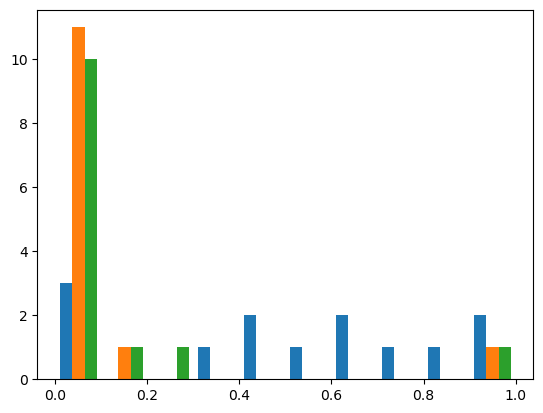

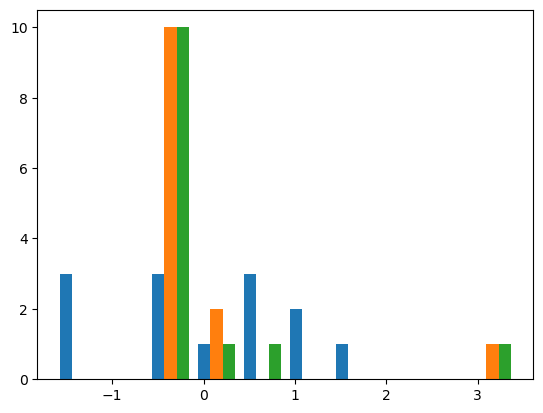

In [7]:
# code to apply scaling and make plots
min_max_scalar = sklearn.preprocessing.MinMaxScaler()
standard_scalar = sklearn.preprocessing.StandardScaler()

min_max_scalar.fit(x_train, y_train)
standard_scalar.fit(x_train, y_train)

min_max_scaled_train = min_max_scalar.transform(x_train)
min_max_scaled_test = min_max_scalar.transform(x_test)
standard_scaled_train = standard_scalar.transform(x_train)
standard_scaled_test = standard_scalar.transform(x_test)

plt.hist(min_max_scaled_train)
plt.show()

plt.hist(standard_scaled_train)
plt.show()

What are the differences between these 3 scaling methods? Make sure to address how the presence of outliers affects each of the methods.

>Outliers have more influence in the standard scalar than in the min_max scalar because it uses the mean which is skewed by the outliers more than the quartiles are. 

Train a 3D kNN with the MinMax Scaler scaled data and another 3D kNN with the Standard Scaler scaled data. Compare the results of both networks with the Robust Scaler kNN results. Compare the predictions for the 5 test instances and the test and train accuracies. Do the predictions change? Which version appears to perform best for this data set?

In [16]:
# Code to build networks and test performance
min_max_scalar.fit(min_max_scaled_train, y_train)
mm_pred_train = knn_model.predict(min_max_scaled_train)
mm_pred_test = knn_model.predict(min_max_scaled_test)
print(sum(abs(mm_pred_train - y_train)))
print(sum(abs(mm_pred_test - y_test)))

standard_scalar.fit(standard_scaled_train, y_train)
std_pred_train = knn_model.predict(standard_scaled_train)
std_pred_test = knn_model.predict(standard_scaled_test)
print(sum(abs(std_pred_train - y_train)))
print(sum(abs(std_pred_test - y_test)))


6
2
6
2


>The test and train accuricies were the same regardless of the original framing. 6/13 were incorrect when using the training model. Interestingly, 2/5 were using the test values. 

For any test set instances where the kNN networks with different scaling methods make different decisions, plot the point and its 3 nearest neighbors for each of the scaling methods. You should use 2 scatter plots to look at the 3 feature dimensions. Why does this point(s) classification change? 

In [17]:
# plotting code here
# I don't know how to do this I'll go to office hours

### Acknowledgement Statement

None